# 🧪 Checkpoint 01 — Mapa da IA Generativa
## Notebook de Desafios · Módulo 1: Fundamentos de IA

| | |
|---|---|
| **Módulo** | 1 — Fundamentos (Aulas 01–04) |
| **Formato** | Individual |
| **Prazo** | 1 semana após a Aula 04 |

---

### 🎯 Cenário

Você é **consultor(a) de IA** contratado(a) por uma empresa. Este notebook contém **código incompleto** — funções com lacunas marcadas por `pass  # IMPLEMENTE`. Seu trabalho é completar o código e interpretar os resultados.

> ⚠️ **Regras:** código 100% gratuito · roda no Colab sem erros · comentários em PT-BR

---
## 🔧 Setup — Execute primeiro (não modifique)

In [ ]:
# Setup - nao modifique
!pip install -q tiktoken sentence-transformers huggingface_hub matplotlib numpy scikit-learn

import tiktoken
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from huggingface_hub import InferenceClient
from google.colab import userdata
import time

try:
    HF_TOKEN = userdata.get("HF_TOKEN")
    print("Token HF carregado")
except:
    HF_TOKEN = None
    print("Configure HF_TOKEN em Colab Secrets")

encoder = tiktoken.get_encoding("cl100k_base")
modelo_emb = SentenceTransformer("all-MiniLM-L6-v2")
print("Setup completo!")

Configure HF_TOKEN em Colab Secrets


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Setup completo!


---
## 🏆 Desafio 1 — Tokenizador de Domínio
**Ref:** Aula 03 — Tokens, BPE, WordPiece

### Problema
A empresa quer entender **quanto custa** processar textos em LLMs. Complete a função `analisar_tokens()` e compare PT-BR vs inglês com 3 textos do seu domínio.

In [ ]:
# DESAFIO 1: Complete a funcao analisar_tokens
def analisar_tokens(texto):
    tokens = encoder.encode(texto)
    return {
        "texto": texto[:60],
        "num_caracteres": len(texto),
        "num_tokens": len(tokens),  # IMPLEMENTE: len dos tokens
        "ratio": len(texto)/len(tokens),       # IMPLEMENTE: caracteres / tokens (float)
        "tokens_decodificados": [encoder.decode([t]) for t in tokens[:10]],  # IMPLEMENTE: decodificar primeiros 10 tokens
                                        # Dica: [encoder.decode([t]) for t in tokens[:10]]
    }

# Teste automatico
teste = analisar_tokens("Inteligencia Artificial esta transformando o mercado.")
assert teste["num_tokens"] > 0, "num_tokens deve ser > 0"
assert isinstance(teste["ratio"], float), "ratio deve ser float"
print(f"Teste passou: {teste}")

Teste passou: {'texto': 'Inteligencia Artificial esta transformando o mercado.', 'num_caracteres': 53, 'num_tokens': 10, 'ratio': 5.3, 'tokens_decodificados': ['Int', 'elig', 'encia', ' Artificial', ' esta', ' transform', 'ando', ' o', ' mercado', '.']}


In [ ]:
# DESAFIO 1 (cont.): Comparar PT-BR vs Ingles
# IMPLEMENTE: 3 pares de textos do SEU dominio (mesmo conteudo, 2 idiomas)
pares = [
    {"pt": "Aprendizado de máquina permite que sistemas melhorem com experiência.",
     "en": "Machine learning allows systems to improve with experience."},
    {"pt": "Redes neurais artificiais são inspiradas no cérebro humano.",
     "en": "Artificial neural networks are inspired by the human brain."},
    {"pt": "Python é a linguagem mais usada em ciência de dados.",
     "en": "Python is the most used language in data science."},
]

print("COMPARACAO PT-BR vs INGLES")
print("=" * 60)
for i, par in enumerate(pares, 1):
    if not par["pt"] or not par["en"]:
        print(f"Par {i} vazio!")
        continue
    a_pt = analisar_tokens(par["pt"])
    a_en = analisar_tokens(par["en"])
    diff = a_pt["num_tokens"] - a_en["num_tokens"]
    print(f"Par {i}: PT={a_pt['num_tokens']} tokens | EN={a_en['num_tokens']} tokens | Diff={diff:+d}")

COMPARACAO PT-BR vs INGLES
Par 1: PT=16 tokens | EN=9 tokens | Diff=+7
Par 2: PT=16 tokens | EN=11 tokens | Diff=+5
Par 3: PT=14 tokens | EN=10 tokens | Diff=+4


---
## 🏆 Desafio 2 — Motor de Similaridade Semântica
**Ref:** Aula 03 — Embeddings, similaridade cosseno

### Problema
A empresa quer encontrar **textos semanticamente similares**. Complete a classe `MotorSimilaridade` e alimente com 6 textos do seu domínio (inclua pares similares e textos diferentes).

In [ ]:
# DESAFIO 2: Complete a classe MotorSimilaridade
class MotorSimilaridade:
    def __init__(self, textos, labels):
        self.textos = textos
        self.labels = labels
        self.embeddings = self.embendings = modelo_emb.encode(textos)  # IMPLEMENTE: modelo_emb.encode(textos)

    def matriz_similaridade(self):
        return cosine_similarity(self.embeddings)  # IMPLEMENTE: cosine_similarity(self.embeddings)

    def mais_similar(self, query):
        emb_q = modelo_emb.encode([query])
        scores = cosine_similarity(emb_q, self.embeddings)[0]  # IMPLEMENTE: cosine_similarity(emb_q, self.embeddings)[0]
        idx = np.argmax(scores)      # IMPLEMENTE: np.argmax(scores)
        return self.labels[idx], float(scores[idx]), self.textos[idx]

    def exibir_matriz(self):
        mat = self.matriz_similaridade()
        header = f"{'':>10}" + "".join(f"{l:>10}" for l in self.labels)
        print(header)
        for i, l in enumerate(self.labels):
            print(f"{l:>10}" + "".join(f"{mat[i][j]:>10.3f}" for j in range(len(self.labels))))

In [ ]:
# DESAFIO 2 (cont.): Alimentar com dados do seu dominio
# IMPLEMENTE: 6 textos (inclua pares similares + textos diferentes)
textos = [
    "Python é amplamente usado para desenvolvimento de software e ciência de dados.",
    "A linguagem Python domina o ecossistema de inteligência artificial.",
    "Redes Wi-Fi utilizam protocolos como IEEE 802.11 para transmissão sem fio.",
    "Bancos de dados relacionais armazenam dados em tabelas com chaves primárias.",
    "SQL é a linguagem padrão para consultar bancos de dados relacionais.",
    "Blockchain é uma tecnologia de registro distribuído e imutável.",
]
labels = ["Python", "Python-IA", "Redes", "BD", "SQL", "Blockchain"] # IMPLEMENTE: labels descritivos

motor = MotorSimilaridade(textos, labels)
print("MATRIZ DE SIMILARIDADE")
motor.exibir_matriz()

# Teste de busca
query = "Quais linguagens são usadas em Machine Learning?"  # IMPLEMENTE: texto novo para buscar o mais similar
if query:
    l, s, t = motor.mais_similar(query)
    print(f"\nQuery: \"{query}\"")
    print(f"Mais similar: [{l}] score={s:.3f}")

MATRIZ DE SIMILARIDADE
              Python Python-IA     Redes        BD       SQLBlockchain
    Python     1.000     0.507     0.232     0.389     0.385     0.257
 Python-IA     0.507     1.000     0.140     0.222     0.339     0.179
     Redes     0.232     0.140     1.000     0.272     0.249     0.213
        BD     0.389     0.222     0.272     1.000     0.689     0.427
       SQL     0.385     0.339     0.249     0.689     1.000     0.419
Blockchain     0.257     0.179     0.213     0.427     0.419     1.000

Query: "Quais linguagens são usadas em Machine Learning?"
Mais similar: [Python-IA] score=0.496


---
## 🏆 Desafio 3 — Mapa Semântico Visual (PCA 2D)
**Ref:** Aula 03 — Visualização de embeddings

### Problema
A diretoria quer **VER** como os textos se relacionam. Complete a função que projeta embeddings em 2D.

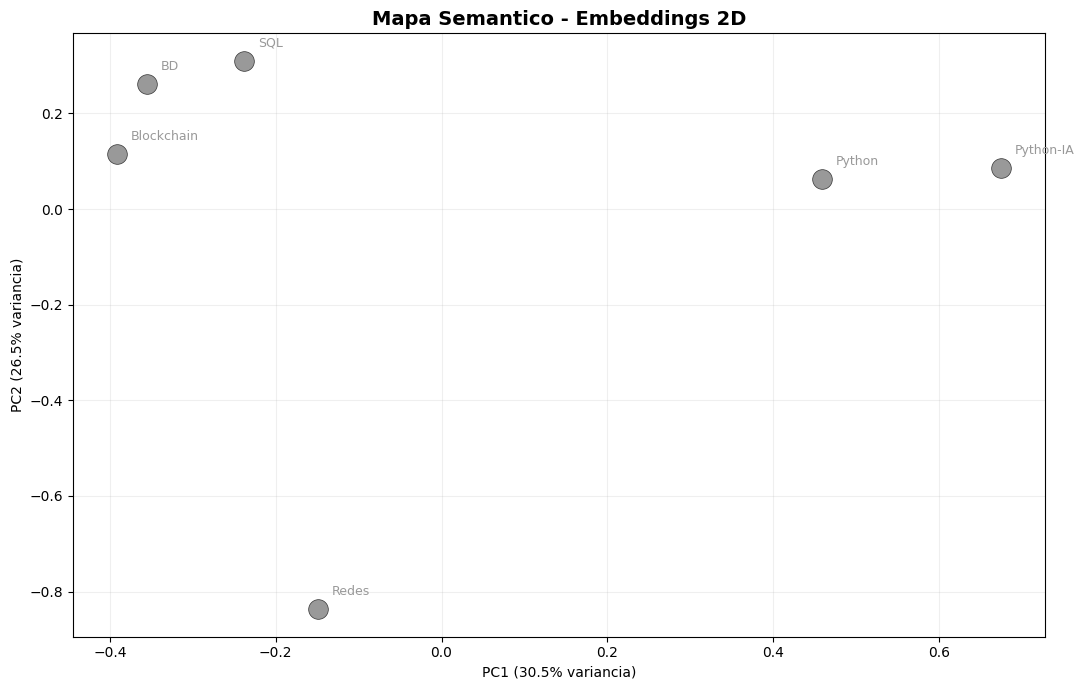

In [ ]:
# DESAFIO 3: Complete a visualizacao PCA
def plotar_mapa(motor, cores_por_label):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(motor.embeddings)  # IMPLEMENTE: pca.fit_transform(motor.embeddings)
    var1 = pca.explained_variance_ratio_[0]    # IMPLEMENTE: pca.explained_variance_ratio_[0]
    var2 = pca.explained_variance_ratio_[1]     # IMPLEMENTE: pca.explained_variance_ratio_[1]

    fig, ax = plt.subplots(figsize=(11, 7))
    for i, (x, y) in enumerate(coords):
        cor = cores_por_label.get(motor.labels[i], "#999")
        ax.scatter(x, y, c=cor, s=200, edgecolors="#333", linewidth= 0.5, zorder=5)  # IMPLEMENTE: ax.scatter(x, y, c=cor, s=200, edgecolors="#333", linewidth=0.5, zorder=5)
        ax.annotate(motor.labels[i], (x, y), textcoords="offset points",
            xytext=(10, 10), fontsize=9, color=cor)  # IMPLEMENTE: ax.annotate(motor.labels[i], (x, y), textcoords="offset points",
              #             xytext=(10, 10), fontsize=9, color=cor)

    ax.set_title("Mapa Semantico - Embeddings 2D", fontsize=14, fontweight="bold")
    ax.set_xlabel(f"PC1 ({var1:.1%} variancia)")
    ax.set_ylabel(f"PC2 ({var2:.1%} variancia)")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# IMPLEMENTE: defina cores para seus labels
cores = {"A": "#ED145B", "B": "#ED145B", "C": "#3D9CCC", "D": "#29AF8C", "E": "#29AF8C", "F": "#7C60C6"}
plotar_mapa(motor, cores)

---
## 🏆 Desafio 4 — Laboratório de Temperatura
**Ref:** Aula 03 (temperatura) + Aula 04 (HuggingFace API)

### Problema
A empresa quer saber qual **temperatura** usar para gerar respostas. Complete a função que testa 3 temperaturas e gera gráfico de consistência.

In [ ]:
# DESAFIO 4: Complete o laboratorio de temperatura
MODELO = "mistralai/Mistral-7B-Instruct-v0.3"
client = InferenceClient(token=HF_TOKEN)

def chamar_llm(prompt, temperature=0.7, max_tokens=200):
    try:
        resp = client.chat_completion(
            model=MODELO,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature, max_tokens=max_tokens,
        )
        return resp.choices[0].message.content.strip()
    except Exception as e:
        return f"Erro: {e}"

def lab_temperatura(prompt, temps=[0.1, 0.7, 1.5], reps=2):
    resultados = {}
    for temp in temps:
        respostas = []
        for _ in range(reps):
            r = chamar_llm(prompt, temperature=temp)  # IMPLEMENTE: chamar_llm com a temperatura atual
            respostas.append(r)
            time.sleep(2)
        unicas = len(set(r[:50] for r in respostas))  # IMPLEMENTE: len(set(r[:50] for r in respostas))
        consistencia = (1 - (unicas - 1 ) / max(reps - 1, 1)) * 100  # IMPLEMENTE: (1 - (unicas-1)/max(reps-1,1)) * 100
        resultados[temp] = {"respostas": respostas, "consistencia": consistencia}
    return resultados

Temp 0.1 - Consistencia: 100%
  [1] Erro: You must provide an api_key to work with auto API or log in with `hf auth login`....
  [2] Erro: You must provide an api_key to work with auto API or log in with `hf auth login`....

Temp 0.7 - Consistencia: 100%
  [1] Erro: You must provide an api_key to work with auto API or log in with `hf auth login`....
  [2] Erro: You must provide an api_key to work with auto API or log in with `hf auth login`....

Temp 1.5 - Consistencia: 100%
  [1] Erro: You must provide an api_key to work with auto API or log in with `hf auth login`....
  [2] Erro: You must provide an api_key to work with auto API or log in with `hf auth login`....



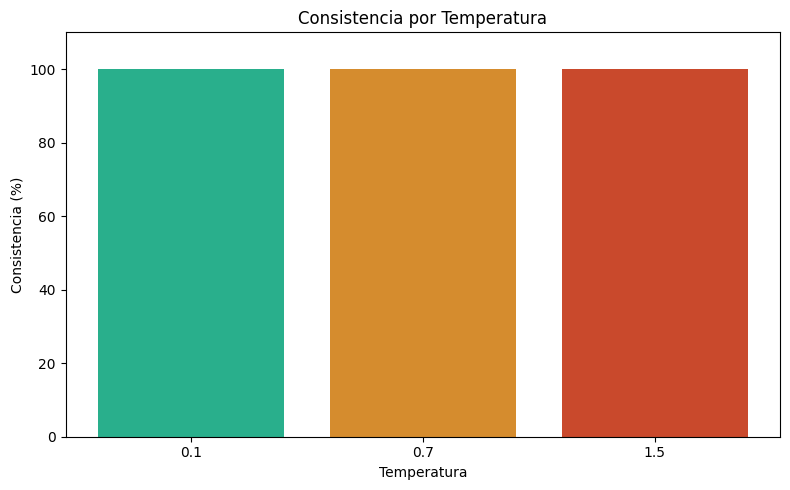

In [ ]:
# DESAFIO 4 (cont.): Executar e visualizar
# IMPLEMENTE: prompt do seu dominio
MEU_PROMPT = "Explique em uma frase o que é programação orientada a objetos."

if MEU_PROMPT:
    res = lab_temperatura(MEU_PROMPT)
    for t, d in res.items():
        print(f"Temp {t} - Consistencia: {d['consistencia']:.0f}%")
        for i, r in enumerate(d["respostas"], 1):
            print(f"  [{i}] {r[:100]}...")
        print()

    # Grafico
    temps = list(res.keys())
    consist = [res[t]["consistencia"] for t in temps]
    plt.figure(figsize=(8, 5))
    plt.bar([str(t) for t in temps], consist, color=["#29AF8C", "#D58C2E", "#C9492C"])
    plt.title("Consistencia por Temperatura")
    plt.xlabel("Temperatura")
    plt.ylabel("Consistencia (%)")
    plt.ylim(0, 110)
    plt.tight_layout()
    plt.show()

---
## 🏆 Desafio 5 — Identificador de Subáreas com Pipelines HF
**Ref:** Aula 02 (subáreas) + Aula 04 (pipelines)

### Problema
Demonstre que diferentes **subáreas de IA** resolvem problemas diferentes. Complete a função e execute 2 pipelines com textos do seu domínio.

In [ ]:
# DESAFIO 5: Complete a funcao de demonstracao de pipeline
from transformers import pipeline
import warnings
warnings.filterwarnings("ignore")

def demonstrar_pipeline(nome, textos, subarea):
    print(f"Pipeline: {nome} | Subarea: {subarea}")
    print("-" * 50)
    pipe = pipeline(nome)  # IMPLEMENTE: pipeline(nome)
    for texto in textos:
        if not texto: continue
        resultado = pipe(texto)  # IMPLEMENTE: pipe(texto)
        print(f"  Input: \"{texto[:60]}\"")
        print(f"  Output: {resultado}\n")

# Pipeline 1: Analise de Sentimento
demonstrar_pipeline(
    "sentiment-analysis",
    ["Python is the best programming language for AI.",
     "This legacy code is terrible and impossible to maintain.",
     "The new framework update fixed most of the bugs."],
    "NLP - Classificação de Sentimento"
)

# Pipeline 2: Escolha outro (ner, summarization, text-generation, fill-mask, etc)
print("=" * 50)
demonstrar_pipeline(
    "text-generation",
    ["The future of software development is",
     "Artificial intelligence will change programming by"],
    "NLP - IA Generativa"
)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Pipeline: sentiment-analysis | Subarea: NLP - Classificação de Sentimento
--------------------------------------------------


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Input: "The future of software development is"
  Output: [{'generated_text': 'The future of software development is not about the design, but about the execution. When you take the time to develop the code, you can see that your company is getting paid more than it deserves.\n\n"We\'re not saying that we can\'t do better," said Matt Miller, director of technology at Microsoft. "We\'re just saying that we can do better."\n\nThe next big step is for Apple to figure out how to attract and retain the best talent in the industry.\n\n"If Microsoft is looking at a billion customers, that\'s probably the best place to start," said Miller. "If it\'s looking at a billion people, it\'s probably the best place to start."\n\nCompanies like Apple are trying to attract talent from around the world. The U.S. government wants to fill that gap by joining the global workforce by 2020.\n\nIt\'s a big step for Apple to make, but it\'ll take time.\n\nWhat does that mean for the future of software developm

---
## ✅ Checklist de Entrega

- [ ] Desafio 1: `analisar_tokens()` funciona + 3 pares PT/EN
- [ ] Desafio 2: `MotorSimilaridade` funciona com 6 textos + busca
- [ ] Desafio 3: Gráfico PCA 2D gerado
- [ ] Desafio 4: 3 temperaturas testadas + gráfico de consistência
- [ ] Desafio 5: 2 pipelines HF executados + subáreas identificadas
- [ ] Textos do domínio da empresa (não genéricos)
- [ ] Notebook roda sem erros

**Exportar:** `CP01_[NomeDoGrupo].ipynb`

---
*FIAP · Ciência da Computação 2026 · Prof. Jorge Luiz Gomes*